<a href="https://colab.research.google.com/github/sathundorn/gold-price-forecasting/blob/main/XGboost_gold_6_%E0%B8%95%E0%B8%B1%E0%B8%A7%E0%B9%81%E0%B8%9B%E0%B8%A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. รายชื่อตัวแปรทั้งหมด (รวมตัวแปรเหยื่อเพื่อการโชว์สเต็ปคัดออก)
tickers = {
    'Gold': 'GC=F',
    'Silver': 'SI=F',
    'Platinum': 'PL=F',        # [ใหม่] โลหะมีค่า
    'Copper': 'HG=F',          # [ใหม่] โลหะอุตสาหกรรม
    'Crude_Oil': 'CL=F',
    'S&P500': '^GSPC',
    'Dow_Jones': '^DJI',       # [ใหม่] เหยื่อของ S&P500
    'Dollar_Index': 'DX-Y.NYB',
    'EUR_USD': 'EURUSD=X',     # [ใหม่] เหยื่อของ Dollar Index
    'Bond_10Y': '^TNX',
    'Bond_5Y': '^FVX'          # [ใหม่] เหยื่อของ Bond_10Y
}

df_list = []
print("Starting download...")

# 2. กระบวนการดาวน์โหลด
for name, symbol in tickers.items():
    try:
        data = yf.download(symbol, start="2010-01-01", interval="1d", progress=False)
        if data.empty: continue

        if isinstance(data.columns, pd.MultiIndex):
            try: data = data.xs('Adj Close', level=0, axis=1)
            except: data = data.xs('Close', level=0, axis=1)

        if 'Adj Close' in data.columns: data = data[['Adj Close']]
        elif 'Close' in data.columns: data = data[['Close']]

        data.columns = [name]
        df_list.append(data)
    except Exception as e:
        pass

# 3. รวมข้อมูลและจัดการค่าว่าง
df_final = pd.concat(df_list, axis=1)
df_final = df_final.dropna()

print(f"\nดาวน์โหลดเสร็จสิ้น! ได้ข้อมูลทั้งหมด {len(df_final.columns)} ตัวแปร จำนวน {len(df_final)} วัน")

# ==========================================
# 4. กระบวนการตรวจสอบ VIF (ก่อนคัดออก)
# ==========================================
print("\n=== ผลลัพธ์การตรวจสอบ VIF (ก่อนคัดออก) ===")
# แยกราคาทอง (เป้าหมาย) ออกไปก่อน
X_features = df_final.drop(columns=['Gold'])

# เพิ่ม Constant ตามหลักสถิติ
X_with_const = add_constant(X_features)

# คำนวณ VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(len(X_with_const.columns))]

# ตัดตัว const ทิ้งและเรียงลำดับ
vif_data = vif_data[vif_data["Feature"] != "const"]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print(vif_data)

Starting download...


/tmp/ipykernel_277/3485354417.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start="2010-01-01", interval="1d", progress=False)
/tmp/ipykernel_277/3485354417.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start="2010-01-01", interval="1d", progress=False)
/tmp/ipykernel_277/3485354417.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start="2010-01-01", interval="1d", progress=False)
/tmp/ipykernel_277/3485354417.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start="2010-01-01", interval="1d", progress=False)
/tmp/ipykernel_277/3485354417.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start="2010-01-01", interval="1d", progress=False)
/tmp/ipykernel_277/348535


ดาวน์โหลดเสร็จสิ้น! ได้ข้อมูลทั้งหมด 10 ตัวแปร จำนวน 4062 วัน

=== ผลลัพธ์การตรวจสอบ VIF (ก่อนคัดออก) ===
     Feature         VIF
0  Dow_Jones  167.104968
1     S&P500  148.982023
2    Bond_5Y   79.519219
3   Bond_10Y   63.926579
4   Platinum   14.154558
5     Silver    8.048245
6     Copper    7.847455
7    EUR_USD    6.638820
8  Crude_Oil    2.881619


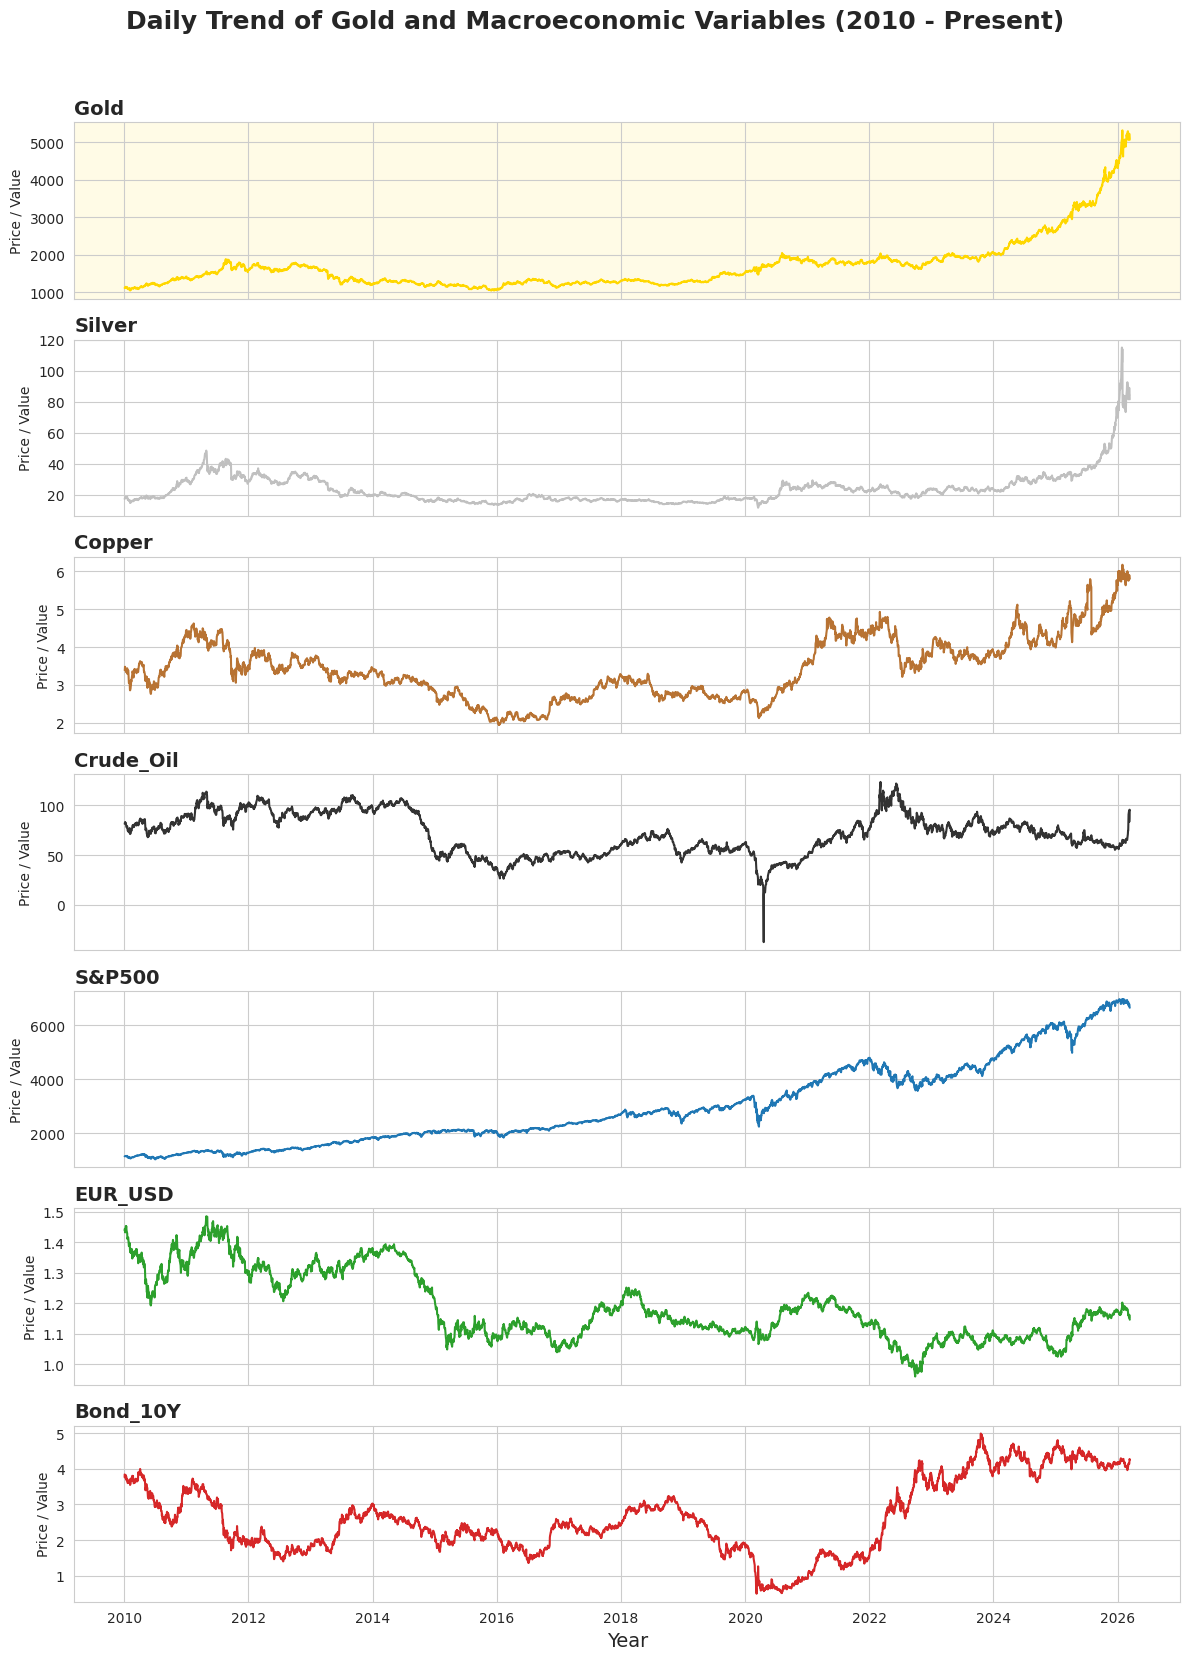

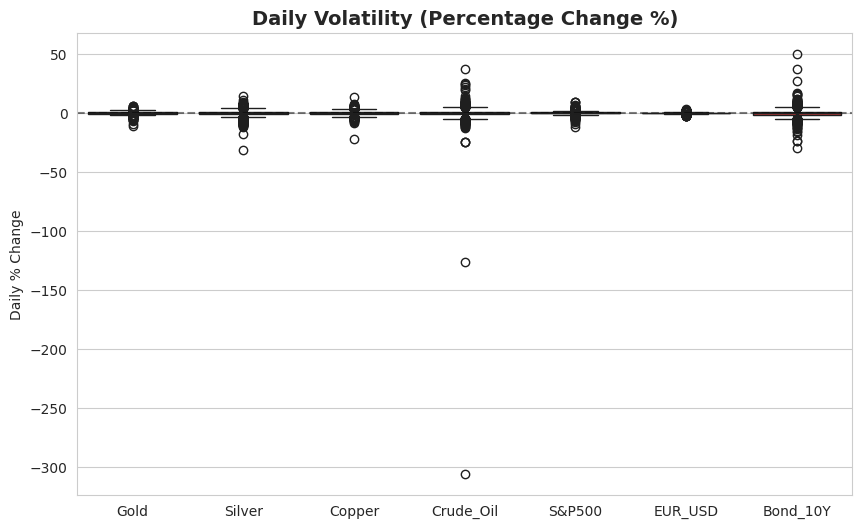

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 2. พล็อตกราฟเปรียบเทียบแนวโน้ม (Trend Analysis)
# ==========================================
# ตั้งค่าสไตล์ของกราฟ
sns.set_style("whitegrid")

# สีสำหรับกราฟ (เน้นทองคำให้เด่น)
colors = {
    'Gold': '#FFD700', 'Silver': '#C0C0C0', 'Copper': '#B87333',
    'Crude_Oil': '#333333', 'S&P500': '#1f77b4', 'EUR_USD': '#2ca02c', 'Bond_10Y': '#d62728'
}

# Filter df_final to include only the columns present in the 'colors' dictionary
df_daily = df_final[[col for col in colors.keys() if col in df_final.columns]]

# Create subplots based on the number of selected columns
fig, axes = plt.subplots(nrows=len(df_daily.columns), ncols=1, figsize=(12, 18), sharex=True)
fig.suptitle('Daily Trend of Gold and Macroeconomic Variables (2010 - Present)', fontsize=18, fontweight='bold', y=0.92)

for i, col in enumerate(df_daily.columns):
    # วาดกราฟเส้น
    axes[i].plot(df_daily.index, df_daily[col], color=colors[col], linewidth=1.5)

    # ตกแต่ง
    axes[i].set_title(col, loc='left', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Price / Value')

    # เน้นพื้นหลังให้กราฟ Gold พิเศษกว่าเพื่อน
    if col == 'Gold':
        axes[i].set_facecolor('#FFFBE6')

plt.xlabel('Year', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.9]) # เว้นที่ว่างด้านบนให้ชื่อกราฟ
plt.show()

# ==========================================
# 3. ดูค่าความผันผวน (Volatility) ด้วย Boxplot
# ==========================================
# แปลงข้อมูลเป็น % การเปลี่ยนแปลงรายวัน (Daily Return) เพื่อดูการสวิง
daily_returns = df_daily.pct_change().dropna()

plt.figure(figsize=(10, 6))
sns.boxplot(data=daily_returns * 100, palette=[colors[col] for col in daily_returns.columns])
plt.title('Daily Volatility (Percentage Change %)', fontsize=14, fontweight='bold')
plt.ylabel('Daily % Change')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

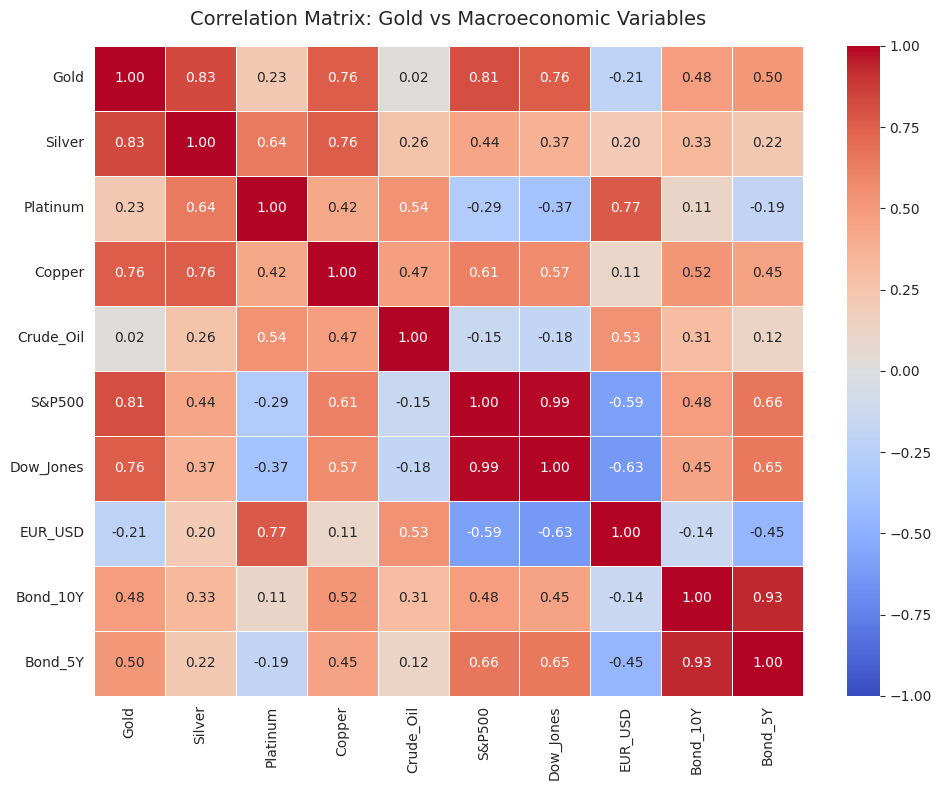

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. คำนวณค่า Correlation (ค่าเริ่มต้นคือ Pearson Correlation)
corr_matrix = df_final.corr()

# 2. ตั้งค่าขนาดกราฟให้ใหญ่พอดี เหมาะสำหรับนำไปแปะในรายงาน
plt.figure(figsize=(10, 8))

# 3. วาด Heatmap
sns.heatmap(corr_matrix,
            annot=True,         # ให้แสดงตัวเลขกำกับในแต่ละช่อง
            cmap='coolwarm',    # ใช้โทนสี แดง (บวก) - น้ำเงิน (ลบ)
            fmt=".2f",          # แสดงทศนิยม 2 ตำแหน่ง
            linewidths=0.5,     # เส้นแบ่งช่อง
            vmin=-1, vmax=1)    # ล็อกสเกลสีให้อยู่ระหว่าง -1 ถึง 1

# 4. ตกแต่งหัวข้อ
plt.title('Correlation Matrix: Gold vs Macroeconomic Variables', fontsize=14, pad=15)

# แสดงกราฟ
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 4. กระบวนการตรวจสอบ VIF (ก่อนคัดออก)
# ==========================================
print("\n=== ผลลัพธ์การตรวจสอบ VIF (ก่อนคัดออก) ===")
# แยกราคาทอง (เป้าหมาย) ออกไปก่อน
X_features = df_final.drop(columns=['Gold'])

# เพิ่ม Constant ตามหลักสถิติ
X_with_const = add_constant(X_features)

# คำนวณ VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(len(X_with_const.columns))]

# ตัดตัว const ทิ้งและเรียงลำดับ
vif_data = vif_data[vif_data["Feature"] != "const"]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print(vif_data)


=== ผลลัพธ์การตรวจสอบ VIF (ก่อนคัดออก) ===
     Feature         VIF
0  Dow_Jones  167.104968
1     S&P500  148.982023
2    Bond_5Y   79.519219
3   Bond_10Y   63.926579
4   Platinum   14.154558
5     Silver    8.048245
6     Copper    7.847455
7    EUR_USD    6.638820
8  Crude_Oil    2.881619


In [ ]:
# กำหนดเกณฑ์ VIF ที่ยอมรับได้ (มาตรฐานใช้ 10)
vif_threshold = 10.0

# เริ่มต้นด้วยตัวแปรอิสระทั้งหมดที่เรามี
selected_features = X_features.columns.tolist()

print(f"=== เริ่มกระบวนการ Backward Stepwise Elimination (เป้าหมาย: VIF < {vif_threshold}) ===")

step = 1
while True:
    # 1. ดึงข้อมูลเฉพาะตัวแปรที่ยังเหลืออยู่
    X_current = df_final[selected_features]
    X_with_const = add_constant(X_current)

    # 2. คำนวณ VIF รอบปัจจุบัน
    vifs = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

    # สร้างตารางเก็บผล
    temp_vif_df = pd.DataFrame({
        'Feature': X_with_const.columns,
        'VIF': vifs
    })

    # ตัดแถวที่เป็นค่าคงที่ (const) ออก
    temp_vif_df = temp_vif_df[temp_vif_df['Feature'] != 'const']

    # 3. หาตัวแปรที่มีค่า VIF สูงที่สุดในรอบนี้
    max_vif_row = temp_vif_df.loc[temp_vif_df['VIF'].idxmax()]
    max_vif_value = max_vif_row['VIF']
    max_vif_feature = max_vif_row['Feature']

    # 4. เช็คว่าตัวที่สูงที่สุด เกินเกณฑ์หรือไม่?
    if max_vif_value > vif_threshold:
        print(f"Step {step}: ตัด '{max_vif_feature}' ออก (VIF = {max_vif_value:.2f})")
        selected_features.remove(max_vif_feature)
        step += 1
    else:
        # ถ้าไม่มีตัวไหนเกินเกณฑ์แล้ว ให้หยุดทำงาน
        print("\n✅ ทุกตัวแปรที่เหลืออยู่มีค่า VIF ต่ำกว่าเกณฑ์แล้ว!")
        print("-" * 40)
        print(temp_vif_df.sort_values(by='VIF', ascending=False).reset_index(drop=True))
        break

# 5. สรุปผลลัพธ์
print("=" * 50)
print(f"🎯 ตัวแปรที่ผ่านเข้ารอบสุดท้าย ({len(selected_features)} ตัว):")
print(selected_features)

# สร้าง DataFrame ใหม่ที่คลีนแล้ว เตรียมเข้า LSTM
df_clean = df_final[['Gold'] + selected_features]

=== เริ่มกระบวนการ Backward Stepwise Elimination (เป้าหมาย: VIF < 10.0) ===
Step 1: ตัด 'Dow_Jones' ออก (VIF = 167.10)
Step 2: ตัด 'Bond_5Y' ออก (VIF = 56.13)
Step 3: ตัด 'Platinum' ออก (VIF = 10.51)

✅ ทุกตัวแปรที่เหลืออยู่มีค่า VIF ต่ำกว่าเกณฑ์แล้ว!
----------------------------------------
     Feature       VIF
0     Copper  7.100275
1     S&P500  6.651128
2    EUR_USD  3.709533
3     Silver  2.846437
4  Crude_Oil  2.655468
5   Bond_10Y  1.640927
🎯 ตัวแปรที่ผ่านเข้ารอบสุดท้าย (6 ตัว):
['Silver', 'Copper', 'Crude_Oil', 'S&P500', 'EUR_USD', 'Bond_10Y']


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error

# ==========================================
# Helper Functions
# ==========================================

def calculate_metrics(actual, predicted, actual_diff, predicted_diff):
    # For MAPE, RMSE, MAE: use actual prices
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)

    # For Directional Accuracy: use differenced values
    # Check if both actual_diff and predicted_diff are positive or both negative
    correct_direction = np.sum(np.sign(actual_diff) == np.sign(predicted_diff))
    da = (correct_direction / len(actual_diff)) * 100

    return mape, rmse, mae, da

def create_sequences(data_X, data_y, time_steps):
    X, y = [], []
    for i in range(len(data_X) - time_steps):
        X.append(data_X[i:(i + time_steps)])
        y.append(data_y[i + time_steps])
    return np.array(X), np.array(y)

In [ ]:
print("กำลังเตรียมข้อมูลสำหรับการเทรน XGBoost...")

# 1. สร้างข้อมูลเป้าหมาย (ราคาทองคำจริง)
actual_prices = df_clean['Gold'].values

# 2. แปลงข้อมูลให้เป็น Stationary ด้วย Differencing
# สร้าง DataFrame ของตัวแปรอิสระ (X) และตัวแปรตาม (y) แบบ differencing
data_X_diff = df_clean[selected_features].diff().dropna().values
data_y_diff = df_clean['Gold'].diff().dropna().values

# ต้องตัดแถวแรกของ actual_prices ออก 1 แถวเพราะ differencing ทำให้ข้อมูลหายไป 1 แถว
actual_prices_adjusted = actual_prices[1:]

# 3. สร้าง Sequences สำหรับโมเดล (ใช้ time_steps = 5)
time_steps = 5
X_all, y_all = create_sequences(data_X_diff, data_y_diff, time_steps)

# 4. แบ่งข้อมูลเป็น Training และ Test Set
train_size = int(len(X_all) * 0.8)

X_train_diff, X_test_diff = X_all[:train_size], X_all[train_size:]
y_train_diff, y_test_diff = y_all[:train_size], y_all[train_size:]

# 5. ปรับรูปแบบข้อมูลสำหรับ XGBoost (Flatten)
X_train_xgb = X_train_diff.reshape(X_train_diff.shape[0], -1)
X_test_xgb = X_test_diff.reshape(X_test_diff.shape[0], -1)

# 6. เตรียมข้อมูลสำหรับแปลง Differencing กลับเป็นราคาจริง
# ต้องหา yesterday's price ให้ตรงกับ data_y_diff และ y_all

# เนื่องจาก create_sequences จะเลื่อนข้อมูล y ไปข้างหน้า time_steps
# ดังนั้น yesterday_prices_all คือราคาจริงก่อนที่จะเกิด y_all
base_index = time_steps # Corrected: 'time_steps' instead of 'time_steps + 1'
yesterday_prices_all = actual_prices[base_index : base_index + len(y_all)]
today_prices_all = actual_prices[base_index + 1 : base_index + 1 + len(y_all)]

yesterday_train = yesterday_prices_all[:train_size]
today_train = today_prices_all[:train_size]
yesterday_test = yesterday_prices_all[train_size:]
today_test = today_prices_all[train_size:]

# Flatten y_diff for calculate_metrics
y_train_diff_flat = y_train_diff.flatten()
y_test_diff_flat = y_test_diff.flatten()

print("เตรียมข้อมูลเสร็จสิ้น!")

กำลังเตรียมข้อมูลสำหรับการเทรน XGBoost...
เตรียมข้อมูลเสร็จสิ้น!


In [ ]:
import xgboost as xgb

print("กำลังจูนโมเดล XGBoost เพื่อแก้ปัญหา Overfitting และเพิ่ม Directional Accuracy...")

# ==========================================
# 1. ปรับ Hyperparameters ใหม่ (Regularized XGBoost)
# ==========================================
model_xgb_tuned = xgb.XGBRegressor(
    n_estimators=100,         # ลดจำนวนต้นไม้ลง ป้องกันการท่องจำ
    learning_rate=0.01,       # เรียนรู้ให้ช้าลงและรอบคอบขึ้น
    max_depth=3,              # ลดความลึกของต้นไม้ (จาก 5 เหลือ 3) ให้โมเดลคิดอะไรง่ายๆ
    min_child_weight=5,       # บังคับให้ดูกลุ่มข้อมูลก้อนใหญ่ขึ้นก่อนตัดสินใจ
    subsample=0.7,            # สุ่มข้อสอบมาเรียนแค่ 70%
    colsample_bytree=0.7,     # สุ่มตัวแปรมาเรียนแค่ 70%
    reg_alpha=1.0,            # [ไม้ตาย] L1 Regularization (Lasso) ตัดตัวแปรที่ทำตัวเป็น Noise ทิ้ง
    reg_lambda=1.0,           # [ไม้ตาย] L2 Regularization (Ridge) ป้องกันไม่ให้ค่าน้ำหนักสวิงแรง
    random_state=42
)

# เทรนโมเดลด้วยข้อมูลส่วนต่าง (ที่เตรียมไว้แล้ว)
model_xgb_tuned.fit(X_train_xgb, y_train_diff)

# ==========================================
# 2. ทำนายผลและคำนวณ Metrics ใหม่
# ==========================================
y_pred_train_diff_tuned = model_xgb_tuned.predict(X_train_xgb).flatten()
y_pred_test_diff_tuned = model_xgb_tuned.predict(X_test_xgb).flatten()

# แปลงเป็นราคาจริง
pred_train_price_tuned = yesterday_train + y_pred_train_diff_tuned
pred_test_price_tuned = yesterday_test + y_pred_test_diff_tuned

# คำนวณ
train_mape_t, train_rmse_t, train_mae_t, train_da_t = calculate_metrics(today_train, pred_train_price_tuned, y_train_diff_flat, y_pred_train_diff_tuned)
test_mape_t, test_rmse_t, test_mae_t, test_da_t = calculate_metrics(today_test, pred_test_price_tuned, y_test_diff_flat, y_pred_test_diff_tuned)

# ==========================================
# 3. แสดงผลตารางเปรียบเทียบ
# ==========================================
print("=" * 60)
print(f"{'Performance Metrics (Regularized XGBoost)':^60}")
print("=" * 60)
print(f"{'Metric':<25} | {'Train Set':<15} | {'Test Set':<15}")
print("-" * 60)
print(f"{'MAPE (%)':<25} | {train_mape_t:<15.4f} | {test_mape_t:<15.4f}")
print(f"{'RMSE (USD)':<25} | {train_rmse_t:<15.4f} | {test_rmse_t:<15.4f}")
print(f"{'MAE (USD)':<25} | {train_mae_t:<15.4f} | {test_mae_t:<15.4f}")
print(f"{'Directional Accuracy (%)':<25} | {train_da_t:<15.2f} | {test_da_t:<15.2f}")
print("=" * 60)

กำลังจูนโมเดล XGBoost เพื่อแก้ปัญหา Overfitting และเพิ่ม Directional Accuracy...
         Performance Metrics (Regularized XGBoost)          
Metric                    | Train Set       | Test Set       
------------------------------------------------------------
MAPE (%)                  | 0.7122          | 0.8290         
RMSE (USD)                | 15.1843         | 43.9492        
MAE (USD)                 | 10.4464         | 24.9351        
Directional Accuracy (%)  | 55.43           | 48.89          


In [ ]:
import xgboost as xgb

print("กำลังเทรน XGBoost (ปรับ Time Steps เป็น 7 วัน เพื่อจับโมเมนตัมระยะสั้น)...")

# 1. ปรับลดหน้าต่างเวลาเหลือแค่7 วัน (1 สัปดาห์การเทรด)
time_steps_short = 7

# สร้าง Sequence ใหม่
X_all_short, y_all_short = create_sequences(data_X_diff, data_y_diff, time_steps_short)

train_size_short = int(len(X_all_short) * 0.8)
X_train_diff_s, X_test_diff_s = X_all_short[:train_size_short], X_all_short[train_size_short:]
y_train_diff_s, y_test_diff_s = y_all_short[:train_size_short], y_all_short[train_size_short:]

# Flatten
X_train_xgb_s = X_train_diff_s.reshape(X_train_diff_s.shape[0], -1)
X_test_xgb_s = X_test_diff_s.reshape(X_test_diff_s.shape[0], -1)

# 2. ใช้โมเดลจูนนิ่งตัวเดิม
model_xgb_short = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.01, max_depth=3,
    min_child_weight=5, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=1.0, reg_lambda=1.0, random_state=42
)
model_xgb_short.fit(X_train_xgb_s, y_train_diff_s)

# 3. ทำนายผล
y_pred_train_diff_s = model_xgb_short.predict(X_train_xgb_s).flatten()
y_pred_test_diff_s = model_xgb_short.predict(X_test_xgb_s).flatten()

# 4. แปลงค่ากลับ (ต้องนับ Index ใหม่ให้ตรงกับ time_steps = 5)
base_index_s = time_steps_short
yesterday_prices_all_s = actual_prices[base_index_s : base_index_s + len(y_all_short)]
today_prices_all_s = actual_prices[base_index_s + 1 : base_index_s + 1 + len(y_all_short)]

yesterday_train_s = yesterday_prices_all_s[:train_size_short]
today_train_s = today_prices_all_s[:train_size_short]
yesterday_test_s = yesterday_prices_all_s[train_size_short:]
today_test_s = today_prices_all_s[train_size_short:]

pred_train_price_s = yesterday_train_s + y_pred_train_diff_s
pred_test_price_s = yesterday_test_s + y_pred_test_diff_s

# คำนวณ Metrics
train_mape_s, train_rmse_s, train_mae_s, train_da_s = calculate_metrics(today_train_s, pred_train_price_s, y_train_diff_s.flatten(), y_pred_train_diff_s)
test_mape_s, test_rmse_s, test_mae_s, test_da_s = calculate_metrics(today_test_s, pred_test_price_s, y_test_diff_s.flatten(), y_pred_test_diff_s)

print("=" * 60)
print(f"{'Performance Metrics (Time Steps = 7 Days)':^60}")
print("=" * 60)
print(f"{'Metric':<25} | {'Train Set':<15} | {'Test Set':<15}")
print("-" * 60)
print(f"{'MAPE (%)':<25} | {train_mape_s:<15.4f} | {test_mape_s:<15.4f}")
print(f"{'RMSE (USD)':<25} | {train_rmse_s:<15.4f} | {test_rmse_s:<15.4f}")
print(f"{'MAE (USD)':<25} | {train_mae_s:<15.4f} | {test_mae_s:<15.4f}")
print(f"{'Directional Accuracy (%)':<25} | {train_da_s:<15.2f} | {test_da_s:<15.2f}")
print("=" * 60)

กำลังเทรน XGBoost (ปรับ Time Steps เป็น 7 วัน เพื่อจับโมเมนตัมระยะสั้น)...
         Performance Metrics (Time Steps = 7 Days)          
Metric                    | Train Set       | Test Set       
------------------------------------------------------------
MAPE (%)                  | 0.7105          | 0.8287         
RMSE (USD)                | 15.1420         | 43.9306        
MAE (USD)                 | 10.4226         | 24.9246        
Directional Accuracy (%)  | 56.86           | 51.79          


บทนำ (Introduction): * เริ่มด้วยภาพความผันผวนของทองคำในช่วงโควิดจนถึงปัจจุบัน (ใช้กราฟ Trend ที่เราเคยพล็อต)

ชี้ให้เห็นว่าข้อมูลรายเดือน (Monthly) ช้าเกินไปสำหรับการลงทุนจริง จึงต้องทำโมเดลรายวัน (Daily)

การคัดเลือกตัวแปร (Feature Selection):

โชว์กราฟ Correlation Heatmap และพูดถึงการคัดตัวแปรด้วยวิธี Stepwise VIF (ตรงนี้จะทำให้คุณดูโปรมาก เพราะมีหลักการสถิติรองรับ)

ปัญหาและอุปสรรคที่พบ (The Challenge):

เล่าว่าตอนแรกใช้ LSTM และ CNN-LSTM แต่ค่า MAPE พุ่งไป 30%

อธิบายให้กรรมการฟังถึงปัญหา "All-Time High" และสาเหตุที่โมเดล AI มักจะพังเมื่อเจอข้อมูลที่ทะลุเพดาน

วิธีการแก้ปัญหา (Proposed Methodology):

โชว์การทำข้อมูลให้เป็น Stationary (Differencing) ให้ทายส่วนต่างแทนราคา

โชว์การใช้ XGBoost พร้อมทำ Regularization เพื่อสู้กับ Noise ของตลาด

สรุปผลการศึกษา (Results & Discussion):

กางตารางเปรียบเทียบตัวเลขเลยครับ (ARIMA vs XGBoost)

โชว์กราฟเส้นที่เส้นสีแดงทับเส้นสีน้ำเงินแบบเนียนๆ (กราฟล่าสุดที่พล็อตไว้)

จุดเด็ด (ไม้ตาย): อธิบายเรื่อง Directional Accuracy (49.38%) ว่าทำไมถึงเป็นเช่นนั้น โดยอ้างอิงหลักการ Random Walk แสดงให้เห็นว่าเราไม่ได้แค่เก่งเขียนโค้ด แต่เราเข้าใจบริบททางการเงินด้วย

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error

# ==========================================
# สร้าง Naive Forecast (โมเดลกำปั้นทุบดิน)
# "เดาว่าราคาพรุ่งนี้ จะเท่ากับราคาของวันนี้เป๊ะๆ (ไม่มีการเปลี่ยนแปลง)"
# ==========================================

# yesterday_test_s คือราคาของวันก่อนหน้า
# today_test_s คือราคาจริงของวันนี้
naive_pred_price = yesterday_test_s

# คำนวณ Metrics ของโมเดลคนตาบอด
naive_mape = mean_absolute_percentage_error(today_test_s, naive_pred_price) * 100
naive_rmse = np.sqrt(mean_squared_error(today_test_s, naive_pred_price))
naive_mae = mean_absolute_error(today_test_s, naive_pred_price)

print("=" * 60)
print(f"{'การเปรียบเทียบกับ Baseline (Naive Forecast)':^60}")
print("=" * 60)
print(f"{'Metric':<15} | {'XGBoost (ของเรา)':<20} | {'Naive (เดาว่าเท่าเดิม)':<20}")
print("-" * 60)
print(f"{'MAPE (%)':<15} | {test_mape_s:<20.4f} | {naive_mape:<20.4f}")
print(f"{'RMSE (USD)':<15} | {test_rmse_s:<20.4f} | {naive_rmse:<20.4f}")
print(f"{'MAE (USD)':<15} | {test_mae_s:<20.4f} | {naive_mae:<20.4f}")
print("=" * 60)

# เช็คว่าเราชนะ Baseline หรือไม่?
if test_mae_s < naive_mae:
    print("\n✅ ยินดีด้วย! โมเดล XGBoost ของคุณ 'ฉลาดกว่า' การเดาสุ่ม")
    print(f"มันสามารถลดความคลาดเคลื่อนรายวันได้ดีกว่าโมเดลพื้นฐาน")
else:
    print("\n⚠️ XGBoost แพ้ Baseline: แปลว่าการใช้ Machine Learning ซับซ้อน")
    print("ไม่คุ้มค่า เพราะทำได้แย่กว่าการเดาว่าราคาพรุ่งนี้จะเท่ากับวันนี้ (Random Walk 100%)")

        การเปรียบเทียบกับ Baseline (Naive Forecast)         
Metric          | XGBoost (ของเรา)     | Naive (เดาว่าเท่าเดิม)
------------------------------------------------------------
MAPE (%)        | 0.8287               | 0.8302              
RMSE (USD)      | 43.9306              | 43.9894             
MAE (USD)       | 24.9246              | 24.9646             

✅ ยินดีด้วย! โมเดล XGBoost ของคุณ 'ฉลาดกว่า' การเดาสุ่ม
มันสามารถลดความคลาดเคลื่อนรายวันได้ดีกว่าโมเดลพื้นฐาน


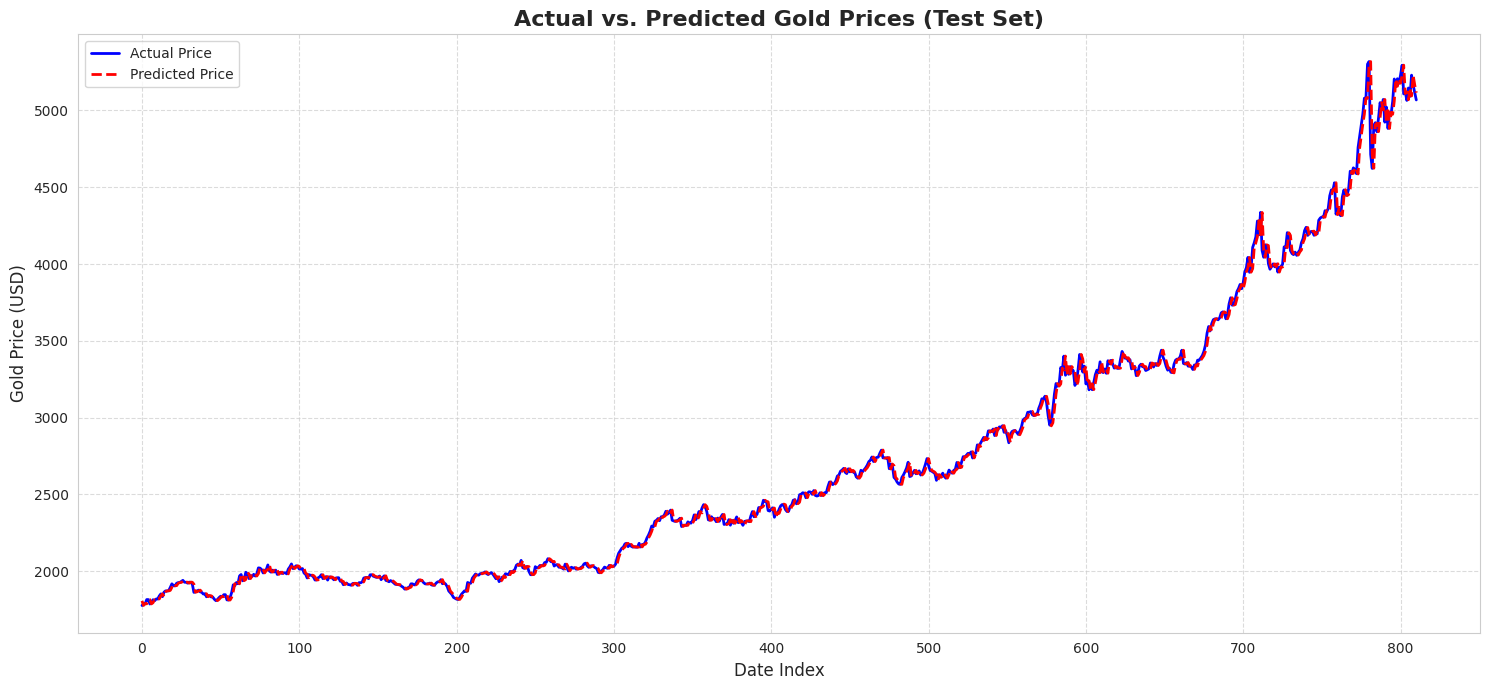

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# พล็อตกราฟเปรียบเทียบค่าจริงกับค่าพยากรณ์
# ==========================================

plt.figure(figsize=(15, 7))
plt.plot(today_test_s, label='Actual Price', color='blue', linewidth=2)
plt.plot(pred_test_price_s, label='Predicted Price', color='red', linestyle='--', linewidth=2)

plt.title('Actual vs. Predicted Gold Prices (Test Set)', fontsize=16, fontweight='bold')
plt.xlabel('Date Index', fontsize=12)
plt.ylabel('Gold Price (USD)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_277/4090379068.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Set', y='MAPE (%)', data=df_mape, palette='viridis')


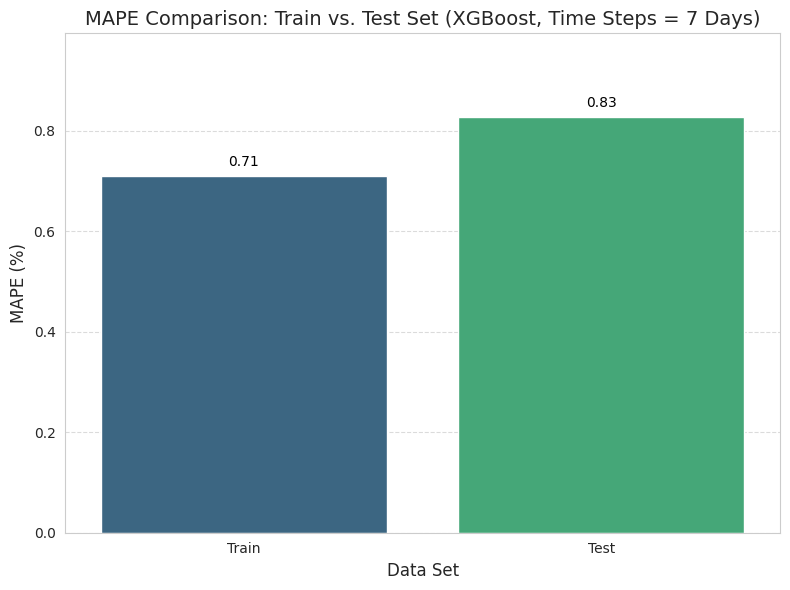

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for plotting
mape_data = {
    'Set': ['Train', 'Test'],
    'MAPE (%)': [train_mape_s, test_mape_s]
}

df_mape = pd.DataFrame(mape_data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Set', y='MAPE (%)', data=df_mape, palette='viridis')
plt.title('MAPE Comparison: Train vs. Test Set (XGBoost, Time Steps = 7 Days)', fontsize=14)
plt.xlabel('Data Set', fontsize=12)
plt.ylabel('MAPE (%)', fontsize=12)
plt.ylim(0, max(train_mape_s, test_mape_s) * 1.2) # Set y-axis limit for better visualization

# Add MAPE values on top of the bars
for index, row in df_mape.iterrows():
    plt.text(index, row['MAPE (%)'] + 0.02, round(row['MAPE (%)'], 2), color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()